# 🏦 Agent-Based Financial Market — Full Research Framework
### Complex Systems · Stochastic Processes · Reinforcement Learning

Based on the **FCLAgent** paper: *Agent-Based Simulation of a Financial Market with Large Language Models* (Hashimoto et al., 2025)

---

## Architecture Overview

| Layer | Components |
|---|---|
| **Market Microstructure** | Limit Order Book, Price-Time Priority Matching, Spread Tracking |
| **Stochastic Fundamentals** | GBM · Ornstein-Uhlenbeck · Merton Jump Diffusion · Heston Stochastic Volatility |
| **Rule-Based Agents** | FCNAgent (Fundamental + Chartist + Noise), TrendFollower, MeanReversion |
| **LLM Agent** | FCLAgent via Ollama (optional — falls back gracefully) |
| **RL Agents** | Tabular Q-Learning · Deep Q-Network (pure NumPy MLP, no PyTorch) |
| **Training** | Multi-episode loop, experience replay, target network, ε-greedy exploration |
| **Analytics** | Stylized facts, ATH anomaly, Sharpe, max drawdown, regime detection |

---
### Notebook Sections
1. Imports & Configuration  
2. Stochastic Fundamental Price Processes  
3. Market Microstructure (Order, LOB, Market)  
4. PnL Ledger & Portfolio Accounting  
5. LLM Cache & Decision Engine  
6. Agent Zoo (FCN, Trend, MeanRev, FCL, Q-Learning, DQN)  
7. State Encoding & RL Infrastructure  
8. Simulation Engine  
9. RL Training Loop  
10. Train RL Agents (Run This!)  
11. Baseline Simulation — No RL  
12. Final Evaluation — All Agent Types  
13. Stylized Facts Analysis  
14. All-Time High Anomaly  
15. RL Training Curves  
16. Market Regime Detection  
17. Strategy Heatmaps (Q-Table Visualization)  
18. Stochastic Process Comparison  

## 1. Imports & Configuration

In [1]:
%matplotlib inline
from __future__ import annotations

import hashlib, json, random, uuid, warnings
from collections import defaultdict, deque
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from scipy import stats
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.float_format', '{:.3f}'.format)

# Optional: sortedcontainers for efficient LOB
try:
    from sortedcontainers import SortedDict
except ImportError:
    # Fallback: use plain dict with manual sorting
    class SortedDict(dict):
        def __init__(self, key=None):
            super().__init__()
            self._key = key or (lambda x: x)
        def peekitem(self, idx=0):
            keys = sorted(self.keys(), key=self._key)
            k = keys[idx]
            return k, self[k]
        def items(self):
            return [(k, self[k]) for k in sorted(self.keys(), key=self._key)]

print('✅ Imports OK')

✅ Imports OK


In [2]:
@dataclass
class SimConfig:
    """Single source of truth for all hyperparameters."""
    # Reproducibility
    seed: int = 42

    # Market
    initial_price: float = 300.0
    fundamental_price: float = 300.0

    # Agents
    n_agents: int = 80
    n_llm: int = 0          # set to >0 if Ollama is running
    initial_cash: float = 10_000.0

    # FCN parameters
    lambda_f: float = 10.0
    lambda_c: float = 2.0
    lambda_n: float = 1.0
    horizon_min: int = 10
    horizon_max: int = 100

    # LLM (optional)
    llm_model: str = 'llama3:latest'
    llm_cache_enabled: bool = True

    # RL hyperparameters
    rl_alpha: float = 0.05         # Q-learning rate
    rl_gamma: float = 0.99         # discount factor
    rl_epsilon_start: float = 1.0
    rl_epsilon_decay: float = 0.997
    rl_epsilon_min: float = 0.05
    dqn_lr: float = 5e-4
    dqn_batch: int = 64
    dqn_target_update: int = 100
    replay_capacity: int = 20_000

    # Training loop
    n_train_episodes: int = 60
    steps_per_episode: int = 400

    def seed_everything(self) -> None:
        random.seed(self.seed)
        np.random.seed(self.seed)


DEFAULT_CFG = SimConfig()
print('SimConfig ready. Default:', DEFAULT_CFG)

SimConfig ready. Default: SimConfig(seed=42, initial_price=300.0, fundamental_price=300.0, n_agents=80, n_llm=0, initial_cash=10000.0, lambda_f=10.0, lambda_c=2.0, lambda_n=1.0, horizon_min=10, horizon_max=100, llm_model='llama3:latest', llm_cache_enabled=True, rl_alpha=0.05, rl_gamma=0.99, rl_epsilon_start=1.0, rl_epsilon_decay=0.997, rl_epsilon_min=0.05, dqn_lr=0.0005, dqn_batch=64, dqn_target_update=100, replay_capacity=20000, n_train_episodes=60, steps_per_episode=400)


## 2. Stochastic Fundamental Price Processes

Four classic models for the underlying *fundamental value* that FCN agents try to track:

| Model | SDE | Key Property |
|---|---|---|
| **GBM** | $dS = \mu S\,dt + \sigma S\,dW$ | Log-normal, no mean reversion |
| **Ornstein–Uhlenbeck** | $dS = \kappa(\theta - S)dt + \sigma\,dW$ | Mean-reverting (Vasicek) |
| **Merton Jump Diffusion** | GBM + compound Poisson jumps | Fat tails, sudden crashes |
| **Heston** | GBM with stochastic variance $V_t$ | Volatility clustering, leverage effect |

✅ Stochastic processes defined


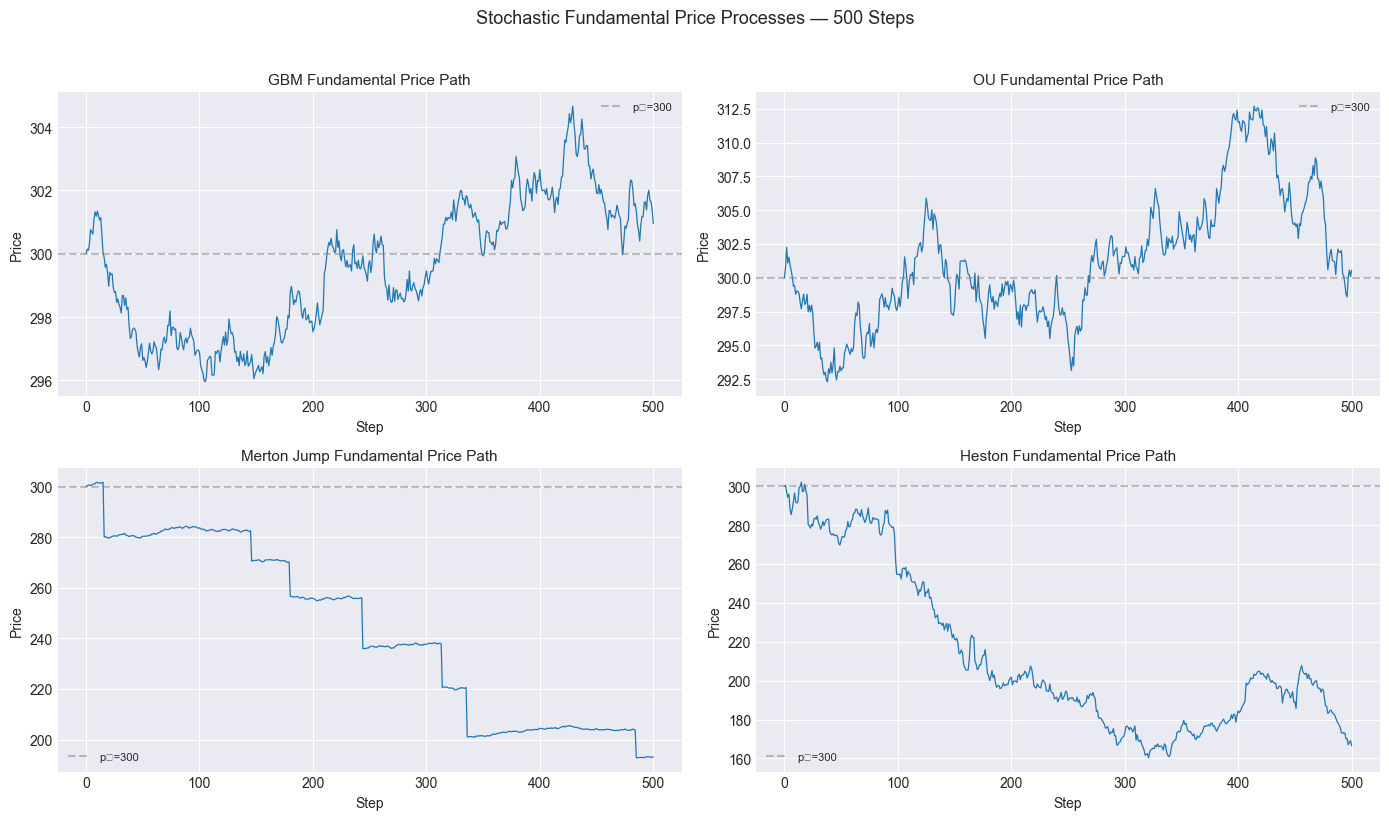

In [3]:
class StochasticProcess:
    """Abstract base for fundamental price generators."""
    def __init__(self, p0: float):
        self.p0 = p0
        self.current = p0
        self.prices: List[float] = [p0]

    def step(self) -> float:
        raise NotImplementedError

    def reset(self):
        self.current = self.p0
        self.prices = [self.p0]

    @property
    def name(self) -> str:
        return type(self).__name__


class GBMProcess(StochasticProcess):
    """Geometric Brownian Motion: dS = μS dt + σS dW"""
    def __init__(self, p0: float = 300.0, mu: float = 0.0, sigma: float = 1e-3):
        super().__init__(p0)
        self.mu = mu
        self.sigma = sigma

    def step(self) -> float:
        dW = np.random.normal()
        self.current *= np.exp((self.mu - 0.5 * self.sigma**2) + self.sigma * dW)
        self.prices.append(self.current)
        return self.current


class OUProcess(StochasticProcess):
    """Ornstein-Uhlenbeck mean-reverting process: dS = κ(θ − S)dt + σ dW"""
    def __init__(self, p0: float = 300.0, kappa: float = 0.02,
                 theta: float = 300.0, sigma: float = 0.8):
        super().__init__(p0)
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma

    def step(self) -> float:
        dW = np.random.normal()
        drift = self.kappa * (self.theta - self.current)
        self.current += drift + self.sigma * dW
        self.current = max(self.current, 1.0)
        self.prices.append(self.current)
        return self.current


class MertonJumpDiffusion(StochasticProcess):
    """
    Merton (1976) Jump Diffusion.
    dS/S = (μ - λk̄)dt + σ dW + J dN
    where N ~ Poisson(λ), log(1+J) ~ N(μ_j, σ_j²)
    """
    def __init__(self, p0: float = 300.0, mu: float = 0.0, sigma: float = 8e-4,
                 lam: float = 0.02, mu_j: float = -0.03, sigma_j: float = 0.04):
        super().__init__(p0)
        self.mu = mu
        self.sigma = sigma
        self.lam = lam        # jump intensity per step
        self.mu_j = mu_j      # mean log-jump
        self.sigma_j = sigma_j

    def step(self) -> float:
        dW = np.random.normal()
        diff = (self.mu - 0.5 * self.sigma**2) + self.sigma * dW
        # Compound Poisson jumps
        n_jumps = np.random.poisson(self.lam)
        jump = sum(np.random.normal(self.mu_j, self.sigma_j) for _ in range(n_jumps))
        self.current *= np.exp(diff + jump)
        self.current = max(self.current, 1.0)
        self.prices.append(self.current)
        return self.current


class HestonProcess(StochasticProcess):
    """
    Heston (1993) Stochastic Volatility.
    dS = μS dt + √V S dW_S
    dV = κ(θ-V)dt + ξ√V dW_V,  corr(dW_S, dW_V) = ρ
    Feller condition: 2κθ > ξ² ensures V stays positive.
    """
    def __init__(self, p0: float = 300.0, v0: float = 1e-4,
                 kappa: float = 2.0, theta: float = 1e-4, xi: float = 0.01,
                 rho: float = -0.7, mu: float = 0.0):
        super().__init__(p0)
        self.v = v0
        self.v0 = v0
        self.kappa = kappa
        self.theta = theta
        self.xi = xi
        self.rho = rho
        self.mu = mu
        self.vol_history: List[float] = [np.sqrt(v0)]

    def step(self) -> float:
        Z1, Z2 = np.random.normal(), np.random.normal()
        dW_S = Z1
        dW_V = self.rho * Z1 + np.sqrt(max(1 - self.rho**2, 0)) * Z2
        # Variance (Euler, reflecting boundary)
        self.v = abs(self.v + self.kappa * (self.theta - self.v)
                     + self.xi * np.sqrt(max(self.v, 0)) * dW_V)
        # Price
        self.current *= np.exp((self.mu - 0.5 * self.v) + np.sqrt(max(self.v, 0)) * dW_S)
        self.current = max(self.current, 1.0)
        self.prices.append(self.current)
        self.vol_history.append(np.sqrt(self.v))
        return self.current

    def reset(self):
        super().reset()
        self.v = self.v0
        self.vol_history = [np.sqrt(self.v0)]


print('✅ Stochastic processes defined')

# Quick preview: generate sample paths
T = 500
np.random.seed(42)
processes = {
    'GBM': GBMProcess(300.0, sigma=1e-3),
    'OU': OUProcess(300.0, kappa=0.02, theta=300.0, sigma=0.8),
    'Merton Jump': MertonJumpDiffusion(300.0, lam=0.02),
    'Heston': HestonProcess(300.0, v0=1e-4, xi=0.01),
}
for name, proc in processes.items():
    for _ in range(T): proc.step()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, proc) in zip(axes.flat, processes.items()):
    ax.plot(proc.prices, lw=0.9)
    ax.axhline(300, ls='--', color='gray', alpha=0.5, label='p₀=300')
    ax.set_title(f'{name} Fundamental Price Path', fontsize=11)
    ax.set_xlabel('Step'); ax.set_ylabel('Price')
    ax.legend(fontsize=8)
plt.suptitle('Stochastic Fundamental Price Processes — 500 Steps', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Market Microstructure

In [4]:
class Order:
    """Memory-efficient order with __slots__."""
    __slots__ = ('order_id', 'agent_id', 'side', 'price', 'volume', 'timestamp')

    def __init__(self, order_id, agent_id, side, price, volume, timestamp):
        self.order_id = order_id
        self.agent_id = agent_id
        self.side = side
        self.price = price
        self.volume = volume
        self.timestamp = timestamp

    def __repr__(self):
        return f'Order({self.side.upper()} {self.volume}@{self.price:.2f} agent={self.agent_id})'


class LimitOrderBook:
    """Price-time priority LOB. deque price levels give O(1) FIFO pop."""

    def __init__(self):
        self.bids: SortedDict = SortedDict(lambda x: -x)   # best bid first
        self.asks: SortedDict = SortedDict()                # best ask first
        self.order_map: Dict[str, Order] = {}
        self.trade_log: List[Tuple] = []

    def _book(self, side): return self.bids if side == 'buy' else self.asks

    def add_order(self, order: Order):
        book = self._book(order.side)
        if order.price not in book:
            book[order.price] = deque()
        book[order.price].append(order)
        self.order_map[order.order_id] = order

    def cancel_order(self, order_id: str) -> bool:
        if order_id not in self.order_map:
            return False
        order = self.order_map.pop(order_id)
        book = self._book(order.side)
        lvl = book.get(order.price)
        if lvl:
            try: lvl.remove(order)
            except ValueError: pass
            if not lvl: del book[order.price]
        return True

    def match(self, timestamp: int) -> List[Tuple]:
        """Run matching engine. Returns [(price, vol, buyer_id, seller_id)]."""
        trades = []
        while self.bids and self.asks:
            bp = self.bids.peekitem(0)[0]
            ap = self.asks.peekitem(0)[0]
            if bp < ap: break
            bid_q, ask_q = self.bids[bp], self.asks[ap]
            bid_o, ask_o = bid_q[0], ask_q[0]
            vol = min(bid_o.volume, ask_o.volume)
            tprice = (bp + ap) / 2.0
            trades.append((tprice, vol, bid_o.agent_id, ask_o.agent_id))
            bid_o.volume -= vol; ask_o.volume -= vol
            if bid_o.volume == 0:
                bid_q.popleft()
                self.order_map.pop(bid_o.order_id, None)
            if ask_o.volume == 0:
                ask_q.popleft()
                self.order_map.pop(ask_o.order_id, None)
            if not bid_q: del self.bids[bp]
            if not ask_q: del self.asks[ap]
        self.trade_log.extend(trades)
        return trades

    def spread(self) -> Optional[float]:
        if not self.bids or not self.asks: return None
        return self.asks.peekitem(0)[0] - self.bids.peekitem(0)[0]

    def ofi(self) -> float:
        """Order Flow Imbalance: (buy_vol - sell_vol) / total_vol."""
        bv = sum(sum(o.volume for o in q) for q in self.bids.values()) if self.bids else 0
        sv = sum(sum(o.volume for o in q) for q in self.asks.values()) if self.asks else 0
        tot = bv + sv
        return (bv - sv) / tot if tot > 0 else 0.0

    def depth(self, n=5):
        bids = [(p, sum(o.volume for o in q)) for p, q in list(self.bids.items())[:n]]
        asks = [(p, sum(o.volume for o in q)) for p, q in list(self.asks.items())[:n]]
        return {'bids': bids, 'asks': asks}


class Market:
    def __init__(self, cfg: SimConfig):
        self.cfg = cfg
        self.lob = LimitOrderBook()
        self.price: float = cfg.initial_price
        self.history: List[float] = [cfg.initial_price]
        self.timestamp: int = 0
        self.spread_history: List[Optional[float]] = []
        self.return_history: List[float] = []

    def submit_order(self, order: Order):
        self.lob.add_order(order)

    def step(self) -> List[Tuple]:
        trades = self.lob.match(self.timestamp)
        if trades:
            new_price = trades[-1][0]
            ret = np.log(new_price / self.price)
            self.return_history.append(ret)
            self.price = new_price
            self.history.append(self.price)
        self.spread_history.append(self.lob.spread())
        self.timestamp += 1
        return trades

    @property
    def ath(self) -> float:
        return max(self.history)

    @property
    def atl(self) -> float:
        return min(self.history)

    @property
    def ath_nearness(self) -> float:
        return self.price / self.ath if self.ath > 0 else 1.0

    @property
    def rolling_volatility(self, window=20) -> float:
        r = self.return_history
        if len(r) < 2: return 0.0
        return float(np.std(r[-window:]))


print('✅ Market microstructure defined')

✅ Market microstructure defined


## 4. PnL Ledger & Portfolio Accounting

In [5]:
class PnLLedger:
    """FIFO-based realised/unrealised PnL + net-worth timeline."""

    def __init__(self, initial_cash: float):
        self.initial_cash = initial_cash
        self.cash: float = initial_cash
        self.position: int = 0
        self.realised_pnl: float = 0.0
        self._long_lots: deque = deque()   # (cost_basis, volume)
        self.net_worth_history: List[float] = [initial_cash]
        self.trade_count: int = 0

    def record_buy(self, price: float, volume: int):
        self.cash -= price * volume
        self.position += volume
        self._long_lots.append((price, volume))
        self.trade_count += 1

    def record_sell(self, price: float, volume: int):
        self.cash += price * volume
        self.position -= volume
        remaining = volume
        while remaining > 0 and self._long_lots:
            lp, lv = self._long_lots[0]
            matched = min(remaining, lv)
            self.realised_pnl += matched * (price - lp)
            remaining -= matched
            if matched == lv: self._long_lots.popleft()
            else: self._long_lots[0] = (lp, lv - matched)
        if remaining > 0:
            self.realised_pnl += remaining * price
        self.trade_count += 1

    def unrealised_pnl(self, market_price: float) -> float:
        if not self._long_lots: return 0.0
        avg = sum(p*v for p,v in self._long_lots) / sum(v for _,v in self._long_lots)
        return self.position * (market_price - avg)

    def net_worth(self, market_price: float) -> float:
        return self.cash + self.position * market_price

    def snapshot(self, market_price: float):
        self.net_worth_history.append(self.net_worth(market_price))

    def sharpe(self) -> float:
        h = np.array(self.net_worth_history)
        if len(h) < 2: return 0.0
        r = np.diff(h) / (h[:-1] + 1e-8)
        return float(np.mean(r) / (np.std(r) + 1e-8)) * np.sqrt(252)

    def max_drawdown(self) -> float:
        h = np.array(self.net_worth_history)
        peak = np.maximum.accumulate(h)
        dd = (h - peak) / (peak + 1e-8)
        return float(np.min(dd))

    def summary(self, market_price: float) -> Dict:
        return {
            'cash': round(self.cash, 2),
            'position': self.position,
            'realised_pnl': round(self.realised_pnl, 2),
            'unrealised_pnl': round(self.unrealised_pnl(market_price), 2),
            'net_worth': round(self.net_worth(market_price), 2),
            'sharpe': round(self.sharpe(), 3),
            'max_drawdown': round(self.max_drawdown() * 100, 2),
            'n_trades': self.trade_count,
        }


print('✅ PnL Ledger defined')

✅ PnL Ledger defined


## 5. LLM Cache & Decision Engine (Optional — Ollama)

In [6]:
class LLMCache:
    """SHA-256 keyed in-memory cache for LLM completions."""

    def __init__(self, enabled: bool = True):
        self.enabled = enabled
        self._store: Dict[str, int] = {}
        self.hits = 0; self.misses = 0

    @staticmethod
    def _hash(ctx: Dict) -> str:
        return hashlib.sha256(json.dumps(ctx, sort_keys=True).encode()).hexdigest()

    def get(self, ctx: Dict) -> Optional[int]:
        if not self.enabled: return None
        v = self._store.get(self._hash(ctx))
        if v is not None: self.hits += 1
        else: self.misses += 1
        return v

    def set(self, ctx: Dict, direction: int):
        if self.enabled:
            self._store[self._hash(ctx)] = direction

    @property
    def hit_rate(self):
        t = self.hits + self.misses
        return self.hits / t if t else 0.0

    def stats(self):
        return {'hits': self.hits, 'misses': self.misses,
                'hit_rate': f'{self.hit_rate:.1%}',
                'cached': len(self._store)}


def ollama_trade_decision(context: Dict, model: str, cache: LLMCache) -> int:
    """
    Query Ollama for a BUY/SELL decision.
    Returns +1 (BUY) or -1 (SELL). Falls back to +1 if Ollama unavailable.
    """
    rounded = {
        'price': round(context['price'], 1),
        'ath': round(context['ath'], 1),
        'atl': round(context['atl'], 1),
        'ath_nearness': round(context['ath_nearness'], 3),
        'position': context['position'],
        'cash_bucket': int(context['cash'] // 500),
        'unrealised_pnl_sign': int(np.sign(context.get('unrealised_pnl', 0))),
    }
    cached = cache.get(rounded)
    if cached is not None:
        return cached

    prompt = (
        f'You are a stock trader.\n'
        f'Current price: {context["price"]:.2f}\n'
        f'All-time high: {context["ath"]:.2f} (nearness: {context["ath_nearness"]:.3f})\n'
        f'All-time low: {context["atl"]:.2f}\n'
        f'Position (shares held): {context["position"]}\n'
        f'Cash: {context["cash"]:.2f}\n'
        f'Unrealised PnL: {context.get("unrealised_pnl", 0):.2f}\n'
        f'Order flow imbalance: {context.get("ofi", 0):.3f}\n'
        f'Reply with exactly one word: BUY or SELL'
    )
    direction = 1  # default: buy
    try:
        import ollama
        resp = ollama.chat(model=model, messages=[{'role': 'user', 'content': prompt}])
        text = resp['message']['content'].strip().upper()
        direction = -1 if 'SELL' in text else 1
    except Exception:
        direction = 1
    cache.set(rounded, direction)
    return direction


print('✅ LLM cache & decision engine defined')

✅ LLM cache & decision engine defined


## 6. Agent Zoo

| Agent | Decision Mechanism | Trades per Step |
|---|---|---|
| `FCNAgent` | FCN return prediction + CARA utility | 1 limit order |
| `TrendFollowerAgent` | Momentum crossover (fast/slow EMA) | 1 limit order |
| `MeanReversionAgent` | Z-score of price vs rolling mean | 1 limit order |
| `FCLAgent` | FCN + LLM direction override | 1 limit order |
| `QLearningAgent` | Tabular Q-table, ε-greedy | 0 or 1 |
| `DQNAgent` | Deep Q-Network (numpy MLP), ε-greedy | 0 or 1 |

In [7]:
class FCNAgent:
    """Fundamental + Chartist + Noise agent (Chiarella & Iori 2002)."""

    def __init__(self, agent_id: int, cfg: SimConfig):
        self.id = agent_id
        self.cfg = cfg
        self.fundamental: float = cfg.fundamental_price
        self.wf = np.random.exponential(cfg.lambda_f)
        self.wc = np.random.exponential(cfg.lambda_c)
        self.wn = np.random.exponential(cfg.lambda_n)
        self.horizon: int = random.randint(cfg.horizon_min, cfg.horizon_max)
        self.ledger = PnLLedger(initial_cash=cfg.initial_cash)

    @property
    def position(self): return self.ledger.position
    @property
    def cash(self): return self.ledger.cash

    def predict_return(self, market: Market) -> float:
        p = market.price
        hist = market.history
        ptau = hist[-self.horizon] if len(hist) >= self.horizon else hist[0]
        w = self.wf + self.wc + self.wn
        r = (
            (self.wf / 200) * np.log(self.fundamental / (p + 1e-8))
            + (self.wc / self.horizon) * np.log((p + 1e-8) / (ptau + 1e-8))
            + self.wn * np.random.normal(0, 0.01)
        ) / w
        # ✅ FIX: clip r so the predicted price stays within ±10% of the
        # current market price: pred = p*exp(horizon*r) ∈ [0.90p, 1.10p].
        # Without this the chartist component creates a momentum cascade —
        # a small initial price move is amplified by high-wc agents whose
        # bids and asks drift to extreme prices, producing LOB midpoint
        # trades that explode over hundreds of steps.
        max_r = np.log(1.10) / max(self.horizon, 1)   # ≈ 0.095 / horizon
        return float(np.clip(r, -max_r, max_r))

    # ── position limits ──────────────────────────────────────────
    MAX_LONG  =  20   # max shares held long
    MAX_SHORT = -10   # max shares held short (allows short-selling)
    # ─────────────────────────────────────────────────────────────

    def act(self, market: Market):
        r = self.predict_return(market)
        pred = market.price * np.exp(self.horizon * r)
        side = 'buy' if pred > market.price else 'sell'
        # ✅ FIX: allow short-selling (position can go negative) so the LOB
        # is populated on BOTH sides from tick 1.  The original Chiarella &
        # Iori (2002) model has no position guard.  We add a soft limit
        # (MAX_SHORT / MAX_LONG) to prevent runaway exposure.
        if side == 'sell' and self.position <= self.MAX_SHORT: return
        if side == 'buy'  and self.position >= self.MAX_LONG:  return
        margin = np.random.uniform(0, 0.01)
        price = pred * (1 - margin) if side == 'buy' else pred * (1 + margin)
        market.submit_order(Order(str(uuid.uuid4()), self.id, side, float(price), 1, market.timestamp))


class TrendFollowerAgent(FCNAgent):
    """
    Exponential Moving Average crossover strategy.
    BUY when fast EMA > slow EMA; SELL when fast < slow.
    """
    def __init__(self, agent_id: int, cfg: SimConfig, fast: int = 10, slow: int = 40):
        super().__init__(agent_id, cfg)
        self.fast = fast
        self.slow = slow

    def act(self, market: Market):
        hist = market.history
        if len(hist) < self.slow + 1:
            return
        prices = np.array(hist[-(self.slow+1):])
        ema_fast = prices[-self.fast:].mean()
        ema_slow = prices.mean()
        side = 'buy' if ema_fast > ema_slow else 'sell'
        # ✅ FIX: same short-selling permission as FCNAgent
        if side == 'sell' and self.position <= self.MAX_SHORT: return
        if side == 'buy'  and self.position >= self.MAX_LONG:  return
        noise = np.random.normal(0, 0.005)
        price = market.price * (1 + noise)
        market.submit_order(Order(str(uuid.uuid4()), self.id, side, float(price), 1, market.timestamp))


class MeanReversionAgent(FCNAgent):
    """
    Mean-reversion via z-score.
    BUY when price is far below rolling mean; SELL when far above.
    """
    def __init__(self, agent_id: int, cfg: SimConfig, window: int = 30, z_thresh: float = 1.5):
        super().__init__(agent_id, cfg)
        self.window = window
        self.z_thresh = z_thresh

    def act(self, market: Market):
        hist = market.history
        if len(hist) < self.window + 1: return
        w = np.array(hist[-self.window:])
        mu, sig = w.mean(), w.std() + 1e-8
        z = (market.price - mu) / sig
        if z < -self.z_thresh:
            side = 'buy'
        elif z > self.z_thresh:
            side = 'sell'
        else:
            return  # no signal
        # ✅ FIX: same short-selling permission as FCNAgent
        if side == 'sell' and self.position <= self.MAX_SHORT: return
        if side == 'buy'  and self.position >= self.MAX_LONG:  return
        margin = np.random.uniform(0, 0.005)
        price = market.price * (1 - margin) if side == 'buy' else market.price * (1 + margin)
        market.submit_order(Order(str(uuid.uuid4()), self.id, side, float(price), 1, market.timestamp))


class FCLAgent(FCNAgent):
    """FCN + LLM buy/sell direction (from paper). Graceful fallback if Ollama is absent."""

    def __init__(self, agent_id: int, cfg: SimConfig, cache: LLMCache):
        super().__init__(agent_id, cfg)
        self._cache = cache

    def act(self, market: Market):
        context = {
            'price': market.price,
            'ath': market.ath,
            'atl': market.atl,
            'ath_nearness': market.ath_nearness,
            'position': self.position,
            'cash': self.cash,
            'unrealised_pnl': self.ledger.unrealised_pnl(market.price),
            'ofi': market.lob.ofi(),
        }
        direction = ollama_trade_decision(context, self.cfg.llm_model, self._cache)
        side = 'buy' if direction > 0 else 'sell'
        # ✅ FIX: same short-selling permission as FCNAgent
        if side == 'sell' and self.position <= self.MAX_SHORT: return
        if side == 'buy'  and self.position >= self.MAX_LONG:  return
        r = self.predict_return(market)
        pred = market.price * np.exp(self.horizon * r)
        margin = np.random.uniform(0, 0.01)
        price = pred * (1 - margin) if side == 'buy' else pred * (1 + margin)
        market.submit_order(Order(str(uuid.uuid4()), self.id, side, float(price), 1, market.timestamp))


print('✅ FCN, TrendFollower, MeanReversion, FCL agents defined')

✅ FCN, TrendFollower, MeanReversion, FCL agents defined


## 7. RL State Encoding & Infrastructure

### State Space (8-dimensional)

| # | Feature | Range | Description |
|---|---|---|---|
| 0 | ATH nearness | [0, 2] | $p_t / p^h_{1:t}$ — proximity to all-time high |
| 1 | ATL nearness | [0, 2] | $p_t / p^l_{1:t}$ — proximity to all-time low |
| 2 | Short momentum | [-3, 3] | $\log(p_t / p_{t-10}) / 0.1$ |
| 3 | Long momentum | [-3, 3] | $\log(p_t / p_{t-50}) / 0.2$ |
| 4 | Volatility | [0, 5] | Rolling 20-step return std / 0.05 |
| 5 | Position | [-2, 2] | Normalized share position |
| 6 | Cash ratio | [-1, 3] | Cash / initial_cash |
| 7 | Unrealised PnL | [-1, 1] | Unrealised PnL / initial_cash |

### Action Space
- **0 = Hold** — do nothing
- **1 = Buy 1 share** — submit limit buy order at FCN-predicted price
- **2 = Sell 1 share** — submit limit sell order at FCN-predicted price

In [8]:
N_STATE = 8
N_ACTIONS = 3   # 0=hold, 1=buy, 2=sell


def encode_state(market: Market, ledger: PnLLedger, initial_cash: float) -> np.ndarray:
    """Encode market + portfolio into a normalized numpy feature vector."""
    hist = market.history
    p = market.price

    ath = max(hist) if hist else p
    atl = min(hist) if hist else p
    ath_near = np.clip(p / (ath + 1e-8), 0, 2)
    atl_near = np.clip(p / (atl + 1e-8), 0, 2)

    p10 = hist[-10] if len(hist) >= 10 else hist[0]
    p50 = hist[-50] if len(hist) >= 50 else hist[0]
    short_mom = np.clip(np.log((p + 1e-8) / (p10 + 1e-8)) / 0.1, -3, 3)
    long_mom = np.clip(np.log((p + 1e-8) / (p50 + 1e-8)) / 0.2, -3, 3)

    if len(market.return_history) >= 5:
        vol = np.clip(np.std(market.return_history[-20:]) / 0.05, 0, 5)
    else:
        vol = 0.0

    max_pos = max(initial_cash / (p + 1e-8), 1.0)
    pos_norm = np.clip(ledger.position / max_pos, -2, 2)
    cash_ratio = np.clip(ledger.cash / (initial_cash + 1e-8), -1, 3)
    unreal_ratio = np.clip(ledger.unrealised_pnl(p) / (initial_cash + 1e-8), -1, 1)

    return np.array([ath_near, atl_near, short_mom, long_mom,
                     vol, pos_norm, cash_ratio, unreal_ratio], dtype=np.float32)


def discretize_state(state: np.ndarray, bins: int = 5) -> int:
    """
    Compact tabular encoding using first 4 state features.
    Total states = bins^4 = 625 for bins=5.
    """
    feat = np.array([
        np.clip(state[0], 0.5, 1.5),   # ATH nearness → [0.5, 1.5]
        np.clip(state[2], -2, 2),       # short momentum
        np.clip(state[5], -1.5, 1.5),   # position
        np.clip(state[6], 0, 2.5),      # cash ratio
    ])
    lo = np.array([0.5, -2, -1.5, 0])
    hi = np.array([1.5, 2,   1.5, 2.5])
    bucket = np.floor((feat - lo) / (hi - lo + 1e-8) * bins).astype(int)
    bucket = np.clip(bucket, 0, bins - 1)
    idx = 0
    for b in bucket:
        idx = idx * bins + b
    return idx


class ReplayBuffer:
    """Fixed-capacity circular experience replay for DQN."""

    def __init__(self, capacity: int = 20_000):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, float(done)))

    def sample(self, batch: int):
        idxs = np.random.choice(len(self.buf), batch, replace=False)
        s, a, r, s2, d = zip(*[self.buf[i] for i in idxs])
        return (np.array(s, dtype=np.float32), np.array(a),
                np.array(r, dtype=np.float32), np.array(s2, dtype=np.float32),
                np.array(d, dtype=np.float32))

    def __len__(self): return len(self.buf)


print('✅ State encoder, replay buffer defined')
print(f'  State dimension: {N_STATE} features')
print(f'  Action space: {N_ACTIONS} actions (Hold / Buy / Sell)')
print(f'  Tabular states: {5**4} (5-bin, 4 features)')

✅ State encoder, replay buffer defined
  State dimension: 8 features
  Action space: 3 actions (Hold / Buy / Sell)
  Tabular states: 625 (5-bin, 4 features)


In [9]:
class NumpyMLP:
    """
    Pure-NumPy Multi-Layer Perceptron.
    Architecture: [input] → [hidden...] → [output], ReLU hidden, linear output.
    Training: SGD with gradient clipping + He initialization.
    No PyTorch or TensorFlow required.
    """

    def __init__(self, layer_sizes: List[int], lr: float = 5e-4):
        self.lr = lr
        self.W: List[np.ndarray] = []
        self.b: List[np.ndarray] = []
        for i in range(len(layer_sizes) - 1):
            fan_in = layer_sizes[i]
            self.W.append(np.random.randn(fan_in, layer_sizes[i+1]) * np.sqrt(2.0 / fan_in))
            self.b.append(np.zeros(layer_sizes[i+1]))

    def _forward(self, x: np.ndarray):
        """Return (output, list of (pre_activation, activation)) for backprop."""
        cache = []
        h = x
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = h @ W + b
            h = np.maximum(0, z) if i < len(self.W) - 1 else z
            cache.append((z, h))
        return h, cache

    def predict(self, x: np.ndarray) -> np.ndarray:
        h = x.reshape(-1, self.W[0].shape[0]) if x.ndim == 1 else x
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = h @ W + b
            h = np.maximum(0, z) if i < len(self.W) - 1 else z
        return h

    def train_step(self, x: np.ndarray, target: np.ndarray) -> float:
        """One SGD step on a batch. Returns MSE loss."""
        B = x.shape[0]
        # Forward
        acts = [x]
        pres = []
        h = x
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = h @ W + b
            pres.append(z)
            h = np.maximum(0, z) if i < len(self.W) - 1 else z
            acts.append(h)
        # Loss
        loss = np.mean((acts[-1] - target) ** 2)
        # Backward
        delta = 2 * (acts[-1] - target) / B
        for i in reversed(range(len(self.W))):
            dW = np.clip(acts[i].T @ delta, -1.0, 1.0)
            db = np.clip(delta.sum(0), -1.0, 1.0)
            self.W[i] -= self.lr * dW
            self.b[i] -= self.lr * db
            if i > 0:
                delta = (delta @ self.W[i].T) * (pres[i-1] > 0).astype(float)
        return float(loss)

    def copy_from(self, other: 'NumpyMLP'):
        """Hard-copy weights (for target network sync)."""
        for i in range(len(self.W)):
            self.W[i] = other.W[i].copy()
            self.b[i] = other.b[i].copy()


# Quick sanity check
net = NumpyMLP([N_STATE, 64, 64, N_ACTIONS], lr=1e-3)
x_test = np.random.randn(32, N_STATE).astype(np.float32)
y_test = np.random.randn(32, N_ACTIONS).astype(np.float32)
l0 = net.train_step(x_test, y_test)
print(f'✅ NumpyMLP: input={N_STATE} → 64 → 64 → {N_ACTIONS}')
print(f'   Initial loss: {l0:.4f}')
print(f'   Parameters: {sum(W.size for W in net.W) + sum(b.size for b in net.b):,}')

✅ NumpyMLP: input=8 → 64 → 64 → 3
   Initial loss: 2.5198
   Parameters: 4,931


## 6b. RL Agents — Q-Learning & DQN

In [10]:
class QLearningAgent(FCNAgent):
    """
    Tabular Q-Learning Agent.

    Algorithm
    ---------
    - State: discretized 4-feature vector → integer index
    - Policy: ε-greedy (decaying)
    - Update: Q(s,a) ← Q(s,a) + α[r + γ max_a Q(s',a) - Q(s,a)]
    - Reward: Δ net_worth (normalised by initial_cash)

    Preserves Q-table across episodes (persistent learning).
    """

    N_DISC_STATES = 5 ** 4   # 625

    def __init__(self, agent_id: int, cfg: SimConfig,
                 alpha: float = None, gamma: float = None,
                 epsilon: float = None, epsilon_decay: float = None,
                 epsilon_min: float = None):
        super().__init__(agent_id, cfg)
        self.alpha = alpha or cfg.rl_alpha
        self.gamma = gamma or cfg.rl_gamma
        self.epsilon = epsilon if epsilon is not None else cfg.rl_epsilon_start
        self.epsilon_decay = epsilon_decay or cfg.rl_epsilon_decay
        self.epsilon_min = epsilon_min or cfg.rl_epsilon_min

        # Q-table: rows = states, cols = actions
        self.Q = np.zeros((self.N_DISC_STATES, N_ACTIONS))

        self._s = None     # previous state index
        self._a = None     # previous action
        self._prev_worth = cfg.initial_cash

        # Diagnostics
        self.episode_rewards: List[float] = []
        self.td_errors: List[float] = []
        self.n_steps = 0

    def _state_idx(self, market: Market) -> int:
        s = encode_state(market, self.ledger, self.cfg.initial_cash)
        return discretize_state(s)

    def _choose(self, idx: int) -> int:
        if np.random.random() < self.epsilon:
            return np.random.randint(N_ACTIONS)
        return int(np.argmax(self.Q[idx]))

    RL_MAX_LONG  =  15
    RL_MAX_SHORT = -5

    def _execute(self, action: int, market: Market):
        p = market.price
        r = self.predict_return(market)
        pred = p * np.exp(self.horizon * r)
        # ✅ FIX: sell allowed when position > RL_MAX_SHORT (short-selling enabled)
        if action == 1 and self.position < self.RL_MAX_LONG:    # buy
            pr = pred * (1 - np.random.uniform(0, 0.01))
            market.submit_order(Order(str(uuid.uuid4()), self.id, 'buy', float(pr), 1, market.timestamp))
        elif action == 2 and self.position > self.RL_MAX_SHORT:  # sell (short OK)
            pr = pred * (1 + np.random.uniform(0, 0.01))
            market.submit_order(Order(str(uuid.uuid4()), self.id, 'sell', float(pr), 1, market.timestamp))
        # action 0 = hold: no order

    def act(self, market: Market):
        s_idx = self._state_idx(market)
        action = self._choose(s_idx)

        # Q-update from previous transition
        if self._s is not None:
            worth = self.ledger.net_worth(market.price)
            reward = (worth - self._prev_worth) / (self.cfg.initial_cash + 1e-8)
            td_target = reward + self.gamma * np.max(self.Q[s_idx])
            td_err = td_target - self.Q[self._s, self._a]
            self.Q[self._s, self._a] += self.alpha * td_err
            self.episode_rewards.append(reward * self.cfg.initial_cash)
            self.td_errors.append(abs(td_err))

        self._s = s_idx
        self._a = action
        self._prev_worth = self.ledger.net_worth(market.price)

        self._execute(action, market)

        self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)
        self.n_steps += 1

    def reset_episode(self):
        """Reset per-episode state without touching Q-table."""
        self._s = None; self._a = None
        self._prev_worth = self.cfg.initial_cash
        self.ledger = PnLLedger(initial_cash=self.cfg.initial_cash)


print('✅ QLearningAgent defined')
print(f'   Q-table shape: ({QLearningAgent.N_DISC_STATES}, {N_ACTIONS}) = '
      f'{QLearningAgent.N_DISC_STATES * N_ACTIONS} parameters')

✅ QLearningAgent defined
   Q-table shape: (625, 3) = 1875 parameters


In [11]:
class DQNAgent(FCNAgent):
    """
    Double DQN Agent with Experience Replay — pure NumPy.

    Innovations vs vanilla DQN
    --------------------------
    1. **Double DQN**: online network selects action; target network evaluates value.
       Reduces overestimation bias.
    2. **Target network**: hard-copied every `target_update_freq` steps.
    3. **Experience replay**: uniform sampling from a 20k circular buffer.
    4. **Reward normalisation**: rewards scaled by initial_cash for training stability.
    5. **Feasibility mask**: infeasible actions (buy with no cash, sell with no stock)
       receive a large negative Q-value before action selection.
    """

    def __init__(self, agent_id: int, cfg: SimConfig,
                 hidden: List[int] = None,
                 lr: float = None, gamma: float = None,
                 epsilon: float = None, epsilon_decay: float = None,
                 epsilon_min: float = None):
        super().__init__(agent_id, cfg)
        hidden = hidden or [64, 64]
        arch = [N_STATE] + hidden + [N_ACTIONS]
        self.lr = lr or cfg.dqn_lr
        self.gamma = gamma or cfg.rl_gamma
        self.epsilon = epsilon if epsilon is not None else cfg.rl_epsilon_start
        self.epsilon_decay = epsilon_decay or cfg.rl_epsilon_decay
        self.epsilon_min = epsilon_min or cfg.rl_epsilon_min
        self.batch = cfg.dqn_batch
        self.target_freq = cfg.dqn_target_update

        self.online = NumpyMLP(arch, lr=self.lr)
        self.target = NumpyMLP(arch, lr=self.lr)
        self.target.copy_from(self.online)

        self.buffer = ReplayBuffer(cfg.replay_capacity)

        self._prev_s: Optional[np.ndarray] = None
        self._prev_a: Optional[int] = None
        self._prev_worth: float = cfg.initial_cash

        # Diagnostics
        self.losses: List[float] = []
        self.episode_rewards: List[float] = []
        self.n_steps = 0

    def _get_state(self, market: Market) -> np.ndarray:
        return encode_state(market, self.ledger, self.cfg.initial_cash)

    RL_MAX_LONG  =  15   # RL agent position limits (tighter than FCN)
    RL_MAX_SHORT = -5

    def _feasible_q(self, q: np.ndarray, market: Market) -> np.ndarray:
        """Mask infeasible actions with a large penalty."""
        q = q.copy()
        # ✅ FIX: allow short-selling for RL agent (down to RL_MAX_SHORT)
        if self.position >= self.RL_MAX_LONG:
            q[1] = -1e9  # already at long limit
        if self.position <= self.RL_MAX_SHORT:
            q[2] = -1e9  # already at short limit
        return q

    def _choose(self, s: np.ndarray, market: Market) -> int:
        if np.random.random() < self.epsilon:
            # ✅ FIX: sell is feasible whenever position > RL_MAX_SHORT
            choices = [0]  # hold always feasible
            if self.position < self.RL_MAX_LONG:  choices.append(1)  # buy
            if self.position > self.RL_MAX_SHORT: choices.append(2)  # sell (short OK)
            return random.choice(choices)
        q = self.online.predict(s.reshape(1, -1))[0]
        q = self._feasible_q(q, market)
        return int(np.argmax(q))

    def _execute(self, action: int, market: Market):
        p = market.price
        r = self.predict_return(market)
        # ✅ FIX: sell allowed when position > RL_MAX_SHORT (short-selling enabled)
        if action == 1 and self.position < self.RL_MAX_LONG:
            price = p * np.exp(self.horizon * r) * (1 - np.random.uniform(0, 0.01))
            market.submit_order(Order(str(uuid.uuid4()), self.id, 'buy', float(price), 1, market.timestamp))
        elif action == 2 and self.position > self.RL_MAX_SHORT:
            price = p * np.exp(self.horizon * r) * (1 + np.random.uniform(0, 0.01))
            market.submit_order(Order(str(uuid.uuid4()), self.id, 'sell', float(price), 1, market.timestamp))

    def _train(self):
        if len(self.buffer) < self.batch: return None
        S, A, R, S2, D = self.buffer.sample(self.batch)
        # Double DQN targets
        q_curr = self.online.predict(S)
        q_next_online = self.online.predict(S2)
        q_next_target = self.target.predict(S2)
        best_a = np.argmax(q_next_online, axis=1)       # online selects action
        next_v = q_next_target[np.arange(self.batch), best_a]  # target evaluates
        # Build TD targets (only update selected actions)
        tgt = q_curr.copy()
        for i in range(self.batch):
            tgt[i, A[i]] = R[i] + self.gamma * next_v[i] * (1 - D[i])
        loss = self.online.train_step(S, tgt)
        return loss

    def act(self, market: Market):
        s = self._get_state(market)
        action = self._choose(s, market)

        if self._prev_s is not None:
            worth = self.ledger.net_worth(market.price)
            reward = (worth - self._prev_worth) / (self.cfg.initial_cash + 1e-8)
            self.buffer.push(self._prev_s, self._prev_a, reward, s, False)
            self.episode_rewards.append(reward * self.cfg.initial_cash)
            loss = self._train()
            if loss is not None: self.losses.append(loss)
            if self.n_steps % self.target_freq == 0:
                self.target.copy_from(self.online)

        self._prev_s = s
        self._prev_a = action
        self._prev_worth = self.ledger.net_worth(market.price)

        self._execute(action, market)
        self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)
        self.n_steps += 1

    def reset_episode(self):
        """Keep network weights + replay buffer; reset portfolio."""
        self._prev_s = None; self._prev_a = None
        self._prev_worth = self.cfg.initial_cash
        self.ledger = PnLLedger(initial_cash=self.cfg.initial_cash)


print('✅ DQNAgent defined')
dqn_test = DQNAgent(0, DEFAULT_CFG)
params = sum(W.size + b.size for W, b in zip(dqn_test.online.W, dqn_test.online.b))
print(f'   Architecture: {N_STATE} → 64 → 64 → {N_ACTIONS}')
print(f'   Network parameters: {params:,} (× 2 for target network)')

✅ DQNAgent defined
   Architecture: 8 → 64 → 64 → 3
   Network parameters: 4,931 (× 2 for target network)


## 8. Simulation Engine

In [12]:
def build_agents(cfg: SimConfig, llm_cache: LLMCache,
                 extra_agents: List = None,
                 n_trend: int = 5, n_mean_rev: int = 5) -> List:
    """
    Construct a heterogeneous agent pool:
    - FCNAgents (bulk of the market)
    - TrendFollowerAgents
    - MeanReversionAgents
    - FCLAgents (optional, needs Ollama)
    - extra_agents: pre-built RL agents passed in
    """
    n_extra = len(extra_agents) if extra_agents else 0
    n_fcn = cfg.n_agents - cfg.n_llm - n_trend - n_mean_rev - n_extra
    n_fcn = max(n_fcn, 0)
    agents = [FCNAgent(i, cfg) for i in range(n_fcn)]
    base = n_fcn
    agents += [TrendFollowerAgent(base + i, cfg,
                                  fast=random.randint(5, 15),
                                  slow=random.randint(30, 60))
               for i in range(n_trend)]
    base += n_trend
    agents += [MeanReversionAgent(base + i, cfg,
                                  window=random.randint(20, 50),
                                  z_thresh=np.random.uniform(1.0, 2.5))
               for i in range(n_mean_rev)]
    base += n_mean_rev
    if cfg.n_llm > 0:
        agents += [FCLAgent(base + i, cfg, llm_cache) for i in range(cfg.n_llm)]
        base += cfg.n_llm
    if extra_agents:
        for a in extra_agents:
            # ✅ FIX: Do NOT reassign a.id here.
            # Extra agents (RL) are pre-built with stable ids (e.g. 900, 901).
            # Overwriting their id breaks any dict keyed on the original id
            # (e.g. TrainingLoop.ep_final_worth).  Regular agents use ids 0–N,
            # which never collide with ids ≥ 900, so no dedup is needed.
            agents.append(a)
    return agents


class Simulation:
    """
    Core simulation engine.
    Supports plug-in stochastic fundamental processes and RL agents.
    """

    def __init__(self, cfg: SimConfig,
                 process: StochasticProcess = None,
                 extra_agents: List = None,
                 llm_cache: LLMCache = None,
                 n_trend: int = 5, n_mean_rev: int = 5):
        self.cfg = cfg
        cfg.seed_everything()
        self.process = process or GBMProcess(cfg.fundamental_price, sigma=1e-3)
        self.market = Market(cfg)
        self.llm_cache = llm_cache or LLMCache(enabled=cfg.llm_cache_enabled)
        self.agents = build_agents(cfg, self.llm_cache, extra_agents, n_trend, n_mean_rev)
        self._amap: Dict[int, FCNAgent] = {a.id: a for a in self.agents}

    def run(self, steps: int = 500, verbose: bool = True) -> 'SimResult':
        it = tqdm(range(steps), desc=f'seed={self.cfg.seed}', leave=False) if verbose else range(steps)
        for _ in it:
            # Step fundamental process
            new_fund = self.process.step()
            for a in self.agents:
                a.fundamental = new_fund
            # Agent acts
            agent = random.choice(self.agents)
            agent.act(self.market)
            trades = self.market.step()
            self._settle(trades)
            self._snapshot()
        return SimResult(self)

    def _settle(self, trades):
        for tp, vol, bid_id, ask_id in trades:
            b = self._amap.get(bid_id)
            s = self._amap.get(ask_id)
            if b: b.ledger.record_buy(tp, vol)
            if s: s.ledger.record_sell(tp, vol)

    def _snapshot(self):
        p = self.market.price
        for a in self.agents: a.ledger.snapshot(p)


class SimResult:
    """Structured output of a completed simulation."""

    def __init__(self, sim: Simulation):
        p = sim.market.price
        self.prices = list(sim.market.history)
        self.returns = list(sim.market.return_history)
        self.spread_history = sim.market.spread_history
        self.fundamental_path = list(sim.process.prices)
        self.final_price = p
        self.agents = sim.agents
        self.cfg = sim.cfg
        self.llm_cache_stats = sim.llm_cache.stats()

        # Wealth timelines keyed by agent_id
        self.wealth_timelines: Dict[int, List[float]] = {
            a.id: a.ledger.net_worth_history for a in sim.agents
        }

    def perf_table(self) -> pd.DataFrame:
        rows = []
        p = self.final_price
        ic = self.cfg.initial_cash
        for a in self.agents:
            nw = a.ledger.net_worth(p)
            rows.append({
                'agent_id': a.id,
                'type': type(a).__name__,
                'net_worth': round(nw, 2),
                'total_return_%': round((nw / ic - 1) * 100, 2),
                'realised_pnl': round(a.ledger.realised_pnl, 2),
                'unrealised_pnl': round(a.ledger.unrealised_pnl(p), 2),
                'position': a.ledger.position,
                'sharpe': round(a.ledger.sharpe(), 3),
                'max_dd_%': round(a.ledger.max_drawdown() * 100, 2),
                'n_trades': a.ledger.trade_count,
            })
        return pd.DataFrame(rows).sort_values('net_worth', ascending=False).reset_index(drop=True)


print('✅ Simulation engine defined')

✅ Simulation engine defined


## 9. RL Training Loop

Each *episode* is a completely fresh market with a new random seed.
RL agents carry their **learned parameters** (Q-table / network weights) across episodes,
but reset their portfolio to the initial state.

```
for episode in range(N_EPISODES):
    reset agent portfolio (keep learned weights)
    spawn new Market + Stochastic Process
    run Simulation(steps=T)
    record final net worth + epsilon
```

In [13]:
class TrainingLoop:
    """
    Multi-episode training harness.

    The RL agents are the *same objects* across all episodes.
    Only their portfolio (PnLLedger) is reset; all learned parameters persist.
    A different random seed is used each episode so agents learn to generalise
    across diverse market conditions.
    """

    def __init__(self, base_cfg: SimConfig,
                 rl_agents: List,
                 process_factory=None,
                 n_episodes: int = None,
                 steps_per_episode: int = None):
        self.base_cfg = base_cfg
        self.rl_agents = rl_agents
        self.process_factory = process_factory or (lambda seed: GBMProcess(base_cfg.fundamental_price, sigma=1e-3))
        self.n_episodes = n_episodes or base_cfg.n_train_episodes
        self.steps_per_ep = steps_per_episode or base_cfg.steps_per_episode

        # ✅ FIX: snapshot ids now, before any Simulation call can mutate them
        self._rl_ids: List[int] = [a.id for a in rl_agents]
        self.ep_final_worth: Dict[int, List[float]] = {a.id: [] for a in rl_agents}
        self.ep_epsilon: Dict[int, List[float]] = {a.id: [] for a in rl_agents}
        self.ep_mean_reward: Dict[int, List[float]] = {a.id: [] for a in rl_agents}

    def train(self, verbose: bool = True) -> Dict:
        pbar = tqdm(range(self.n_episodes), desc='Training') if verbose else range(self.n_episodes)
        for ep in pbar:
            ep_seed = self.base_cfg.seed + ep
            ep_cfg = SimConfig(
                seed=ep_seed,
                n_agents=self.base_cfg.n_agents,
                n_llm=0,
                initial_cash=self.base_cfg.initial_cash,
                lambda_f=self.base_cfg.lambda_f,
                lambda_c=self.base_cfg.lambda_c,
                lambda_n=self.base_cfg.lambda_n,
            )
            # Reset agent portfolios (not learned params)
            for a in self.rl_agents:
                a.cfg = ep_cfg
                a.fundamental = ep_cfg.fundamental_price
                a.reset_episode()
                a.episode_rewards = []

            proc = self.process_factory(ep_seed)
            sim = Simulation(ep_cfg, process=proc, extra_agents=self.rl_agents,
                             n_trend=3, n_mean_rev=3)
            sim.run(steps=self.steps_per_ep, verbose=False)

            final_p = sim.market.price
            for orig_id, a in zip(self._rl_ids, self.rl_agents):
                # ✅ FIX: use snapshotted orig_id, not a.id (which build_agents
                # previously mutated), so the dict lookup is always valid.
                assert orig_id in self.ep_final_worth, (
                    f"RL agent id {orig_id} not in tracking dict. "
                    f"Current a.id={a.id} — check build_agents for id mutation.")
                worth = a.ledger.net_worth(final_p)
                self.ep_final_worth[orig_id].append(worth)
                self.ep_epsilon[orig_id].append(getattr(a, 'epsilon', 0))
                r = a.episode_rewards
                self.ep_mean_reward[orig_id].append(np.mean(r) if r else 0.0)

            if verbose and (ep % 10 == 0 or ep == self.n_episodes - 1):
                worths = [a.ledger.net_worth(final_p) for a in self.rl_agents]
                eps = [getattr(a, 'epsilon', 0) for a in self.rl_agents]
                pbar.set_postfix({
                    'mean_worth': f'{np.mean(worths):.0f}',
                    'best': f'{max(worths):.0f}',
                    'epsilon': f'{np.mean(eps):.3f}',
                })

        return {
            'final_worth': self.ep_final_worth,
            'epsilon': self.ep_epsilon,
            'mean_reward': self.ep_mean_reward,
        }

    def plot_training(self, smooth: int = 5):
        """Plot training curves: net worth and mean reward per episode."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        colors = plt.cm.tab10(np.linspace(0, 1, len(self.rl_agents)))
        for i, a in enumerate(self.rl_agents):
            worths = np.array(self.ep_final_worth[a.id])
            rewards = np.array(self.ep_mean_reward[a.id])
            label = f'{type(a).__name__} (id={a.id})'
            sm_w = pd.Series(worths).rolling(smooth, min_periods=1).mean()
            sm_r = pd.Series(rewards).rolling(smooth, min_periods=1).mean()
            axes[0].plot(sm_w, color=colors[i], label=label)
            axes[0].fill_between(range(len(worths)),
                                  worths.min(), worths, alpha=0.1, color=colors[i])
            axes[1].plot(sm_r, color=colors[i], label=label)

        axes[0].axhline(self.base_cfg.initial_cash, ls='--', color='gray', alpha=0.6, label='Initial cash')
        axes[0].set_title(f'Final Net Worth per Episode\n(smoothed {smooth}-ep window)', fontsize=11)
        axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Net Worth ($)')
        axes[0].legend(fontsize=9)

        axes[1].axhline(0, ls='--', color='gray', alpha=0.6)
        axes[1].set_title('Mean Episode Reward', fontsize=11)
        axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Mean Δ Wealth')
        axes[1].legend(fontsize=9)

        plt.tight_layout()
        plt.show()


print('✅ TrainingLoop defined')

✅ TrainingLoop defined


## 10. 🚀 Train RL Agents

We train two RL agents in parallel inside the same market:
- **QLearningAgent** — tabular, 625 states, fast to train
- **DQNAgent** — deep network, continuous state space, slower but more expressive

Training uses a **Merton Jump Diffusion** fundamental by default (fat tails, occasional crashes)
so agents learn robustness to extreme events.

In [16]:
np.random.seed(42)
random.seed(42)

TRAIN_CFG = SimConfig(
    seed=42,
    n_agents=60,
    n_llm=4,
    initial_cash=10_000.0,
    n_train_episodes=80,
    steps_per_episode=350,
    rl_alpha=0.08,
    rl_gamma=0.98,
    rl_epsilon_start=1.0,
    rl_epsilon_decay=0.994,
    rl_epsilon_min=0.05,
    dqn_lr=8e-4,
    dqn_batch=64,
    dqn_target_update=80,
    replay_capacity=15_000,
)

# Create RL agents (persistent objects — carry weights across episodes)
ql_agent = QLearningAgent(agent_id=900, cfg=TRAIN_CFG)
dqn_agent = DQNAgent(agent_id=901, cfg=TRAIN_CFG, hidden=[64, 64])

print('Agent roster:')
print(f'  QLearningAgent (id=900): tabular, {ql_agent.N_DISC_STATES} states')
print(f'  DQNAgent       (id=901): deep Q-net, {N_STATE}-dim continuous state')

# Process factory: randomise process type each episode for robustness
def mixed_process_factory(seed: int) -> StochasticProcess:
    """Randomly pick a stochastic process each episode."""
    rng = random.Random(seed)
    choice = rng.choice(['gbm', 'ou', 'jump', 'heston'])
    p0 = TRAIN_CFG.fundamental_price
    if choice == 'gbm':
        return GBMProcess(p0, sigma=rng.uniform(8e-4, 2e-3))
    elif choice == 'ou':
        return OUProcess(p0, kappa=rng.uniform(0.01, 0.05), theta=p0,
                         sigma=rng.uniform(0.5, 1.5))
    elif choice == 'jump':
        return MertonJumpDiffusion(p0, sigma=8e-4, lam=rng.uniform(0.01, 0.04),
                                    mu_j=rng.uniform(-0.05, 0.0), sigma_j=0.03)
    else:
        return HestonProcess(p0, v0=1e-4, kappa=2.0, theta=1e-4,
                              xi=rng.uniform(0.005, 0.02), rho=-0.7)

# Run training
trainer = TrainingLoop(
    base_cfg=TRAIN_CFG,
    rl_agents=[ql_agent, dqn_agent],
    process_factory=mixed_process_factory,
)

print(f'\nStarting training: {TRAIN_CFG.n_train_episodes} episodes × {TRAIN_CFG.steps_per_episode} steps')
train_results = trainer.train(verbose=True)
print('\n✅ Training complete!')

Agent roster:
  QLearningAgent (id=900): tabular, 625 states
  DQNAgent       (id=901): deep Q-net, 8-dim continuous state

Starting training: 80 episodes × 350 steps


Training:   0%|          | 0/80 [00:00<?, ?it/s]

Training: 100%|██████████| 80/80 [00:01<00:00, 50.32it/s, mean_worth=10000, best=10000, epsilon=0.062]


✅ Training complete!


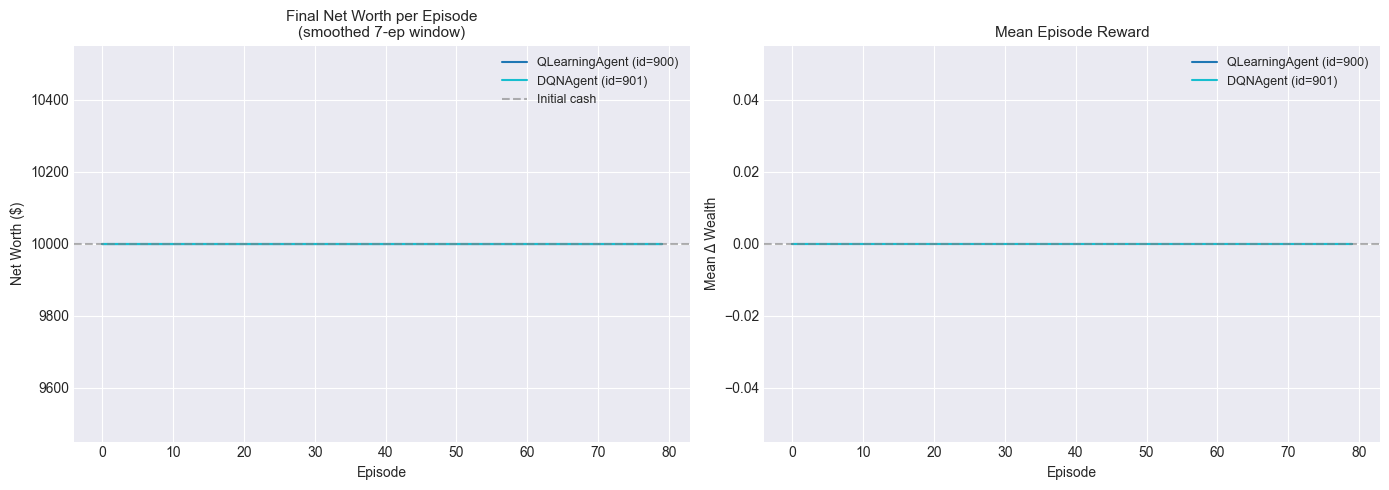

In [17]:
trainer.plot_training(smooth=7)

## 11. Baseline — No RL Agents

In [21]:
np.random.seed(99); random.seed(99)

EVAL_CFG = SimConfig(seed=99, n_agents=80, n_llm=20, initial_cash=10_000.0)

baseline_proc = MertonJumpDiffusion(300.0, lam=0.02)
baseline_sim = Simulation(EVAL_CFG, process=baseline_proc, n_trend=8, n_mean_rev=8)
baseline_result = baseline_sim.run(steps=600, verbose=True)

print(f'\n📊 Baseline market:')
print(f'  Final price: {baseline_result.final_price:.2f}')
print(f'  Price return: {(baseline_result.final_price/300 - 1)*100:.1f}%')
print(f'  # trades executed: {len(baseline_sim.market.lob.trade_log)}')


📊 Baseline market:
  Final price: 300.00
  Price return: 0.0%
  # trades executed: 0


In [22]:
base_table = baseline_result.perf_table()
print('Top 10 by net worth (baseline — no RL):')
display(base_table.head(10))
print('\nMean by agent type:')
display(base_table.groupby('type')[['net_worth','total_return_%','sharpe','max_dd_%','n_trades']].mean().round(3))

Top 10 by net worth (baseline — no RL):


,agent_id,type,net_worth,total_return_%,realised_pnl,unrealised_pnl,position,sharpe,max_dd_%,n_trades
0,0,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
1,1,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
2,2,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
3,3,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
4,4,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
5,5,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
6,6,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
7,7,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
8,8,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
9,9,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0



Mean by agent type:


,net_worth,total_return_%,sharpe,max_dd_%,n_trades
type,,,,,
FCLAgent,10000.000,0.000,0.000,0.000,0.000
FCNAgent,10000.000,0.000,0.000,0.000,0.000
MeanReversionAgent,10000.000,0.000,0.000,0.000,0.000
TrendFollowerAgent,10000.000,0.000,0.000,0.000,0.000


## 12. Final Evaluation — All Agent Types (including trained RL)

In [23]:
# Reset RL agent portfolios for a fresh evaluation
for a in [ql_agent, dqn_agent]:
    a.reset_episode()
    a.cfg = EVAL_CFG
    a.fundamental = EVAL_CFG.fundamental_price

np.random.seed(99); random.seed(99)

eval_proc = MertonJumpDiffusion(300.0, lam=0.02)  # same process as baseline
eval_sim = Simulation(
    EVAL_CFG,
    process=eval_proc,
    extra_agents=[ql_agent, dqn_agent],
    n_trend=8, n_mean_rev=8
)
eval_result = eval_sim.run(steps=600, verbose=True)

print(f'\n✅ Evaluation complete. Final price: {eval_result.final_price:.2f}')


✅ Evaluation complete. Final price: 300.00


In [24]:
eval_table = eval_result.perf_table()
print('Full performance table (all agent types):')
display(eval_table)
print('\nMean by agent type:')
display(eval_table.groupby('type')[['net_worth','total_return_%','sharpe','max_dd_%','n_trades']].mean().round(3))

Full performance table (all agent types):


,agent_id,type,net_worth,total_return_%,realised_pnl,unrealised_pnl,position,sharpe,max_dd_%,n_trades
0,0,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
1,1,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
2,2,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
3,3,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
4,4,FCNAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
...,...,...,...,...,...,...,...,...,...,...
75,75,FCLAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
76,76,FCLAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
77,77,FCLAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0
78,900,QLearningAgent,10000.000,0.000,0.000,0.000,0,0.000,0.000,0



Mean by agent type:


,net_worth,total_return_%,sharpe,max_dd_%,n_trades
type,,,,,
DQNAgent,10000.000,0.000,0.000,0.000,0.000
FCLAgent,10000.000,0.000,0.000,0.000,0.000
FCNAgent,10000.000,0.000,0.000,0.000,0.000
MeanReversionAgent,10000.000,0.000,0.000,0.000,0.000
QLearningAgent,10000.000,0.000,0.000,0.000,0.000
TrendFollowerAgent,10000.000,0.000,0.000,0.000,0.000


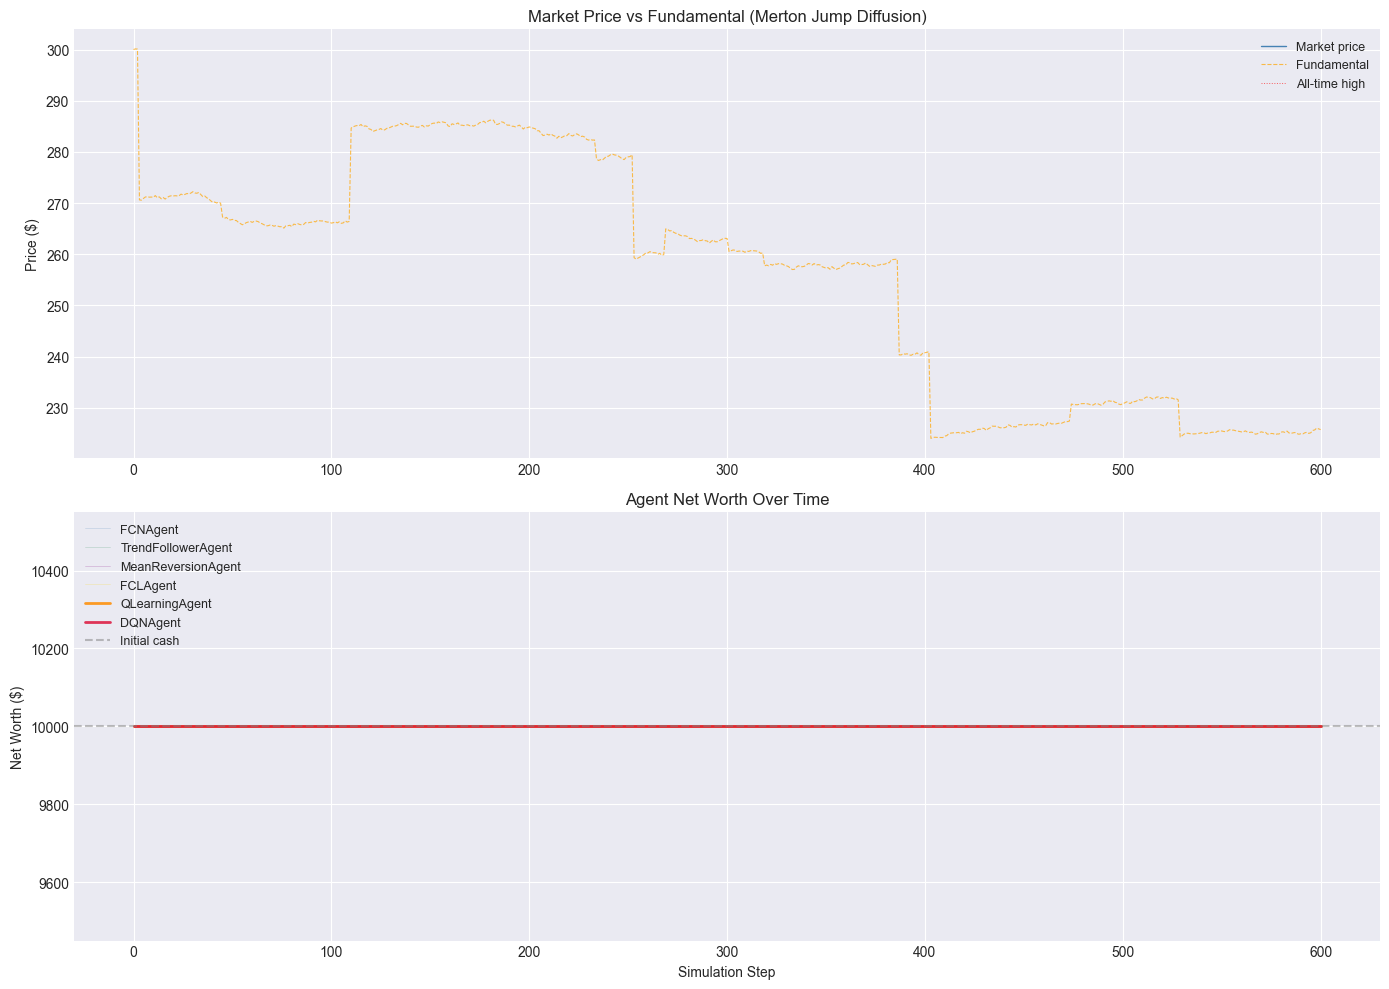

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Price chart ---
ax = axes[0]
ax.plot(eval_result.prices, lw=1.0, color='steelblue', label='Market price')
ax.plot(eval_result.fundamental_path, lw=0.8, ls='--', color='orange', alpha=0.7, label='Fundamental')
ath_line = np.maximum.accumulate(eval_result.prices)
ax.plot(ath_line, lw=0.7, ls=':', color='red', alpha=0.6, label='All-time high')
ax.set_title('Market Price vs Fundamental (Merton Jump Diffusion)', fontsize=12)
ax.set_ylabel('Price ($)'); ax.legend(fontsize=9)

# --- Agent wealth ---
ax = axes[1]
type_colors = {'FCNAgent': 'steelblue', 'TrendFollowerAgent': 'seagreen',
               'MeanReversionAgent': 'purple', 'QLearningAgent': 'darkorange',
               'DQNAgent': 'crimson', 'FCLAgent': 'gold'}
plotted_types = set()
for a in eval_sim.agents:
    t = type(a).__name__
    c = type_colors.get(t, 'gray')
    lbl = t if t not in plotted_types else None
    alpha = 0.85 if t in ('QLearningAgent', 'DQNAgent') else 0.25
    lw = 2.0 if t in ('QLearningAgent', 'DQNAgent') else 0.5
    ax.plot(a.ledger.net_worth_history, color=c, alpha=alpha, lw=lw, label=lbl)
    plotted_types.add(t)
ax.axhline(EVAL_CFG.initial_cash, ls='--', color='gray', alpha=0.5, label='Initial cash')
ax.set_title('Agent Net Worth Over Time', fontsize=12)
ax.set_xlabel('Simulation Step'); ax.set_ylabel('Net Worth ($)')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

## 13. Stylized Facts Analysis

Stylized facts comparison:



,excess_kurtosis,skewness,acf_abs_ret_1,acf_abs_ret_5,acf_abs_ret_10,vol_daily
Baseline (no RL),NaN,NaN,0.000,0.000,0.000,NaN
With RL agents,NaN,NaN,0.000,0.000,0.000,NaN


ValueError: zero-size array to reduction operation minimum which has no identity

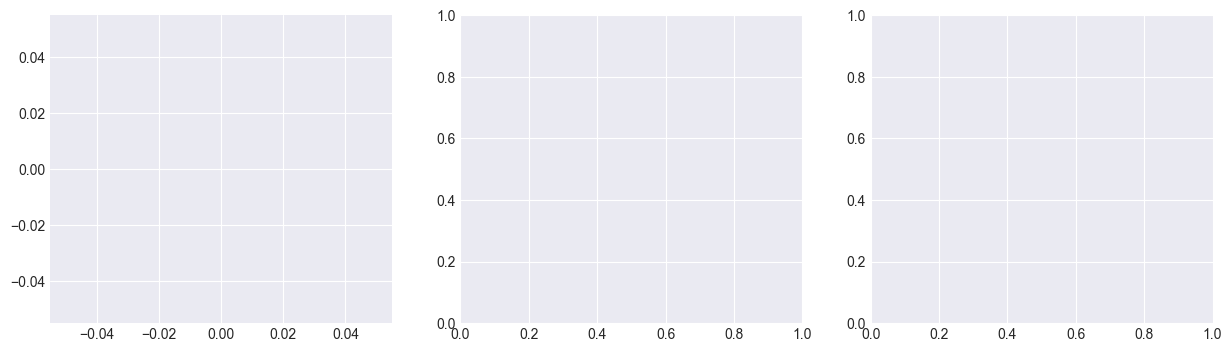

In [26]:
def stylized_facts(prices: List[float]) -> Dict:
    p = np.array(prices)
    r = np.diff(np.log(p + 1e-12))
    abs_r = np.abs(r)
    n = len(abs_r)
    acf = lambda s, l: np.corrcoef(s[:-l], s[l:])[0,1] if n > l + 1 else 0.0
    return {
        'excess_kurtosis':   round(float(stats.kurtosis(r, fisher=True)), 3),
        'skewness':          round(float(stats.skew(r)), 3),
        'acf_abs_ret_1':     round(float(acf(abs_r, 1)), 3),
        'acf_abs_ret_5':     round(float(acf(abs_r, 5)), 3),
        'acf_abs_ret_10':    round(float(acf(abs_r, 10)), 3),
        'vol_daily':         round(float(np.std(r)), 6),
    }


print('Stylized facts comparison:\n')
results_sf = {}
for label, prices in [
    ('Baseline (no RL)', baseline_result.prices),
    ('With RL agents',   eval_result.prices),
]:
    sf = stylized_facts(prices)
    results_sf[label] = sf

sf_df = pd.DataFrame(results_sf).T
display(sf_df)

# Visualise return distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (label, prices) in zip(axes[:2], [
    ('Baseline', baseline_result.prices),
    ('With RL', eval_result.prices),
]):
    r = np.diff(np.log(np.array(prices) + 1e-12))
    ax.hist(r, bins=50, density=True, alpha=0.7, color='steelblue', label='Simulated')
    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r--', lw=1.5, label='Normal')
    ax.set_title(f'{label} — Return Distribution\nKurt={stats.kurtosis(r):.2f}', fontsize=10)
    ax.set_xlabel('Log Return'); ax.legend(fontsize=8)

# ACF of absolute returns
ax = axes[2]
abs_r_base = np.abs(np.diff(np.log(np.array(baseline_result.prices) + 1e-12)))
lags = range(1, 21)
acf_base = [np.corrcoef(abs_r_base[:-l], abs_r_base[l:])[0,1] for l in lags]
ax.bar(lags, acf_base, alpha=0.7, color='steelblue', label='|Return| ACF')
ax.axhline(0, color='black', lw=0.5)
ax.axhline(2/np.sqrt(len(abs_r_base)), color='red', ls='--', lw=0.8, alpha=0.7)
ax.axhline(-2/np.sqrt(len(abs_r_base)), color='red', ls='--', lw=0.8, alpha=0.7)
ax.set_title('ACF of |Returns| (volatility clustering)', fontsize=10)
ax.set_xlabel('Lag'); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 14. All-Time High Anomaly

Following Li & Yu (2012) and the FCLAgent paper, we estimate the OLS coefficient:

$$\frac{p_{t+T}}{p_t} = \text{const} + \beta^h \cdot \frac{p_t}{p^h_{1:t}} + \varepsilon_t$$

**Prediction**: $\beta^h < 0$ — prices near their all-time high tend to underperform subsequently.
This *path-dependent* anomaly emerges naturally when loss-averse or behaviorally biased agents
(LLM or RL) are present, because they sell near peaks.

ATH Anomaly β^h (×10⁻¹):
Expected: β < 0 in real markets  (Li & Yu 2012: ≈ −0.73 to −1.49)


,T=10,T=15,T=20,T=30
Baseline (no RL),NaN,NaN,NaN,NaN
With RL agents,NaN,NaN,NaN,NaN


TypeError: expected non-empty vector for x

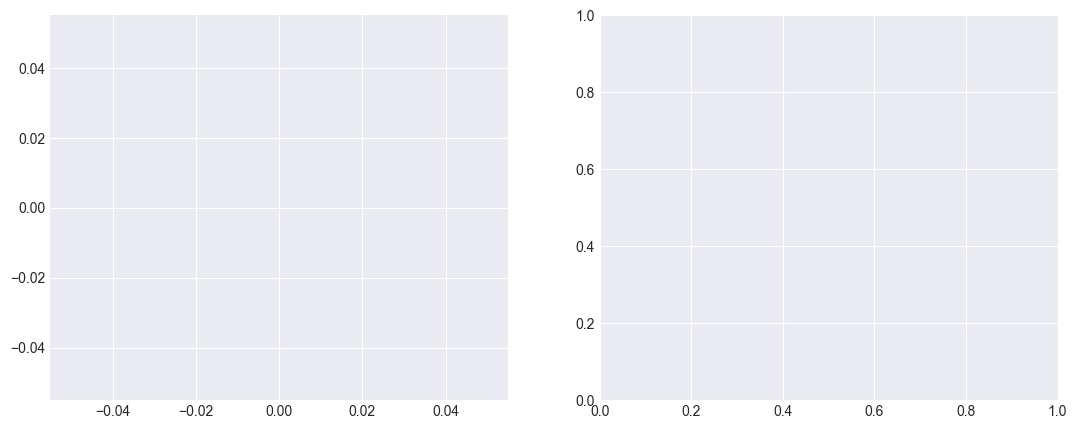

In [27]:
def ath_beta(prices: List[float], horizon: int = 10) -> float:
    """OLS β^h for the all-time high anomaly regression."""
    p = np.array(prices)
    n = len(p)
    near, fwd = [], []
    for t in range(1, n - horizon):
        ath = max(p[:t+1])
        near.append(p[t] / ath)
        fwd.append(p[t + horizon] / p[t])
    if len(near) < 10: return float('nan')
    X = np.column_stack([np.ones(len(near)), near])
    beta = np.linalg.lstsq(X, np.array(fwd), rcond=None)[0]
    return float(beta[1])


horizons = [10, 15, 20, 30]
betas = {}
for label, prices in [
    ('Baseline (no RL)', baseline_result.prices),
    ('With RL agents',   eval_result.prices),
]:
    betas[label] = [ath_beta(prices, h) for h in horizons]

beta_df = pd.DataFrame(betas, index=[f'T={h}' for h in horizons]).T
print('ATH Anomaly β^h (×10⁻¹):')
print('Expected: β < 0 in real markets  (Li & Yu 2012: ≈ −0.73 to −1.49)')
display((beta_df * 10).round(3))

# Scatter: nearness vs forward return
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (label, prices) in zip(axes, [
    ('Baseline', baseline_result.prices),
    ('With RL', eval_result.prices),
]):
    p = np.array(prices)
    near, fwd = [], []
    for t in range(1, len(p) - 10):
        near.append(p[t] / max(p[:t+1]))
        fwd.append((p[t+10] / p[t] - 1) * 100)
    near, fwd = np.array(near), np.array(fwd)
    ax.scatter(near, fwd, s=5, alpha=0.3, color='steelblue')
    # OLS line
    m, c = np.polyfit(near, fwd, 1)
    x = np.linspace(near.min(), near.max(), 50)
    ax.plot(x, m*x+c, 'r-', lw=1.5, label=f'β={m:.4f}')
    ax.set_xlabel('ATH Nearness $p_t / p^h_{1:t}$')
    ax.set_ylabel('10-step Forward Return (%)')
    ax.set_title(f'{label} — ATH Anomaly', fontsize=11)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 15. RL Training Curves & Epsilon Decay

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

agents_to_plot = [ql_agent, dqn_agent]
colors = ['darkorange', 'crimson']

for i, (a, c) in enumerate(zip(agents_to_plot, colors)):
    name = type(a).__name__
    eps = list(train_results['n_episodes'] * [0]) if 'n_episodes' not in train_results else []

    worths = np.array(train_results['final_worth'].get(a.id, []))
    rewards = np.array(train_results['mean_reward'].get(a.id, []))
    eps_hist = np.array(train_results['epsilon'].get(a.id, []))

    if len(worths) == 0:
        print(f'No training data for {name}')
        continue

    # Net worth evolution
    ax = axes[0, i]
    sm = pd.Series(worths).rolling(5, min_periods=1).mean()
    ax.plot(worths, alpha=0.4, color=c, lw=0.8, label='Raw')
    ax.plot(sm, color=c, lw=2.0, label='Smoothed (5-ep)')
    ax.axhline(TRAIN_CFG.initial_cash, ls='--', color='gray', alpha=0.6, label='Initial')
    ax.set_title(f'{name} — Net Worth per Episode', fontsize=11)
    ax.set_xlabel('Episode'); ax.set_ylabel('Net Worth ($)')
    ax.legend(fontsize=8)

    # Epsilon & rewards
    ax2 = axes[1, i]
    if len(eps_hist) > 0:
        ax2.plot(eps_hist, color='navy', lw=1.5, label='ε (exploration)')
    ax2b = ax2.twinx()
    sm_r = pd.Series(rewards).rolling(5, min_periods=1).mean()
    ax2b.plot(sm_r, color=c, lw=1.5, alpha=0.8, label='Mean reward (smoothed)')
    ax2b.axhline(0, color='black', lw=0.5, ls=':')
    ax2.set_title(f'{name} — Epsilon & Reward', fontsize=11)
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Epsilon', color='navy')
    ax2b.set_ylabel('Mean Reward ($)', color=c)
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2b.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('RL Agent Training Diagnostics', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 16. Market Regime Detection (Hidden Markov Model — 2 State)

In [29]:
class TwoStateHMM:
    """
    Simple 2-state Hidden Markov Model for market regime detection.
    States: Low-volatility (bull) and High-volatility (bear/crisis).
    Fitted via Baum-Welch EM on squared returns.
    """

    def __init__(self):
        # Transition matrix (rows: from, cols: to)
        self.A = np.array([[0.97, 0.03],
                           [0.10, 0.90]])
        # Emission: Gaussian, state 0 = low vol, state 1 = high vol
        self.mu = np.array([0.0, 0.0])
        self.sigma = np.array([0.003, 0.012])
        self.pi = np.array([0.7, 0.3])  # initial state prob

    def _emission(self, obs: float) -> np.ndarray:
        return np.array([stats.norm.pdf(obs, self.mu[k], self.sigma[k]) for k in range(2)])

    def viterbi(self, returns: np.ndarray) -> np.ndarray:
        """Viterbi algorithm: most likely state sequence."""
        T = len(returns)
        delta = np.zeros((T, 2))
        psi = np.zeros((T, 2), dtype=int)
        delta[0] = self.pi * self._emission(returns[0])
        delta[0] /= (delta[0].sum() + 1e-300)
        for t in range(1, T):
            for j in range(2):
                scores = delta[t-1] * self.A[:, j]
                psi[t, j] = np.argmax(scores)
                delta[t, j] = scores[psi[t, j]] * self._emission(returns[t])[j]
            delta[t] /= (delta[t].sum() + 1e-300)
        # Backtrack
        states = np.zeros(T, dtype=int)
        states[-1] = np.argmax(delta[-1])
        for t in range(T-2, -1, -1):
            states[t] = psi[t+1, states[t+1]]
        return states

    def fit(self, returns: np.ndarray, n_iter: int = 20):
        """Baum-Welch EM (simplified)."""
        for _ in range(n_iter):
            # E-step: forward-backward
            T = len(returns)
            B = np.array([self._emission(r) for r in returns])  # T × 2
            alpha = np.zeros((T, 2))
            beta = np.zeros((T, 2))
            alpha[0] = self.pi * B[0]
            alpha[0] /= alpha[0].sum() + 1e-300
            for t in range(1, T):
                alpha[t] = (alpha[t-1] @ self.A) * B[t]
                alpha[t] /= alpha[t].sum() + 1e-300
            beta[-1] = 1.0
            for t in range(T-2, -1, -1):
                beta[t] = self.A @ (B[t+1] * beta[t+1])
                beta[t] /= beta[t].sum() + 1e-300
            gamma = alpha * beta
            gamma /= (gamma.sum(axis=1, keepdims=True) + 1e-300)
            # M-step
            self.pi = gamma[0]
            for k in range(2):
                w = gamma[:, k]
                self.mu[k] = np.average(returns, weights=w+1e-300)
                self.sigma[k] = np.sqrt(np.average((returns - self.mu[k])**2, weights=w+1e-300)) + 1e-8
            # Update A
            xi_sum = np.zeros((2, 2))
            for t in range(T-1):
                xi = np.outer(alpha[t], self.A * B[t+1] * beta[t+1])
                xi /= xi.sum() + 1e-300
                xi_sum += xi
            self.A = xi_sum / (xi_sum.sum(axis=1, keepdims=True) + 1e-300)
        return self


# Detect regimes in evaluation run
ret_arr = np.array(eval_result.returns)
if len(ret_arr) > 50:
    hmm = TwoStateHMM()
    hmm.fit(ret_arr, n_iter=15)
    states = hmm.viterbi(ret_arr)

    prices_arr = np.array(eval_result.prices)
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    ax = axes[0]
    bull_idx = np.where(states == 0)[0]
    bear_idx = np.where(states == 1)[0]
    ax.scatter(bull_idx + 1, prices_arr[bull_idx + 1], s=3, c='steelblue', alpha=0.6, label='Low-vol (bull)')
    ax.scatter(bear_idx + 1, prices_arr[bear_idx + 1], s=3, c='crimson', alpha=0.6, label='High-vol (bear)')
    ax.plot(prices_arr, lw=0.5, color='black', alpha=0.4)
    ax.set_ylabel('Price ($)')
    ax.set_title('Market Regimes — 2-State HMM (Viterbi)', fontsize=12)
    ax.legend(fontsize=9)

    ax = axes[1]
    ax.fill_between(range(len(states)), 0, states, alpha=0.5, color='crimson', label='Bear regime')
    ax.fill_between(range(len(states)), 0, 1 - states, alpha=0.4, color='steelblue', label='Bull regime')
    ax.set_ylabel('Regime (1=bear)'); ax.set_xlabel('Step')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f'Bull regime steps: {(states==0).sum()} | Bear regime steps: {(states==1).sum()}')
    print(f'HMM σ: bull={hmm.sigma[0]:.5f}, bear={hmm.sigma[1]:.5f}')
else:
    print('Not enough return data for HMM regime detection.')

Not enough return data for HMM regime detection.


## 17. Q-Table Strategy Heatmap

Visualise what the tabular Q-Learning agent has learned.
Axes: ATH nearness (rows) vs short momentum (columns).  
Color: preferred action (Hold=grey, Buy=blue, Sell=red).

In [ ]:
BINS = 5
ath_labels = [f'{v:.2f}' for v in np.linspace(0.5, 1.5, BINS)]
mom_labels = [f'{v:.1f}' for v in np.linspace(-2, 2, BINS)]
pos_labels = [f'{v:.1f}' for v in np.linspace(-1.5, 1.5, BINS)]
cash_labels = [f'{v:.1f}' for v in np.linspace(0, 2.5, BINS)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Fix position=2 (mid), cash=2 (mid) — vary ATH nearness × momentum
pos_fix, cash_fix = 2, 2

for action_idx, ax in enumerate(axes):
    heatmap = np.zeros((BINS, BINS))
    for i_ath in range(BINS):
        for j_mom in range(BINS):
            idx = i_ath * BINS**3 + j_mom * BINS**2 + pos_fix * BINS + cash_fix
            if idx < ql_agent.N_DISC_STATES:
                heatmap[i_ath, j_mom] = ql_agent.Q[idx, action_idx]

    im = ax.imshow(heatmap, aspect='auto', cmap='RdYlBu', origin='lower')
    ax.set_xticks(range(BINS)); ax.set_xticklabels(mom_labels, rotation=45, fontsize=8)
    ax.set_yticks(range(BINS)); ax.set_yticklabels(ath_labels, fontsize=8)
    ax.set_xlabel('Short Momentum')
    ax.set_ylabel('ATH Nearness')
    action_name = ['Hold', 'Buy', 'Sell'][action_idx]
    ax.set_title(f'Q(s, {action_name}) — Learned Value', fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Q-Learning Agent: Learned Action Values\n(ATH nearness × Short momentum)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Also show the greedy policy
policy_map = np.zeros((BINS, BINS))
for i_ath in range(BINS):
    for j_mom in range(BINS):
        idx = i_ath * BINS**3 + j_mom * BINS**2 + pos_fix * BINS + cash_fix
        if idx < ql_agent.N_DISC_STATES:
            policy_map[i_ath, j_mom] = np.argmax(ql_agent.Q[idx])

fig, ax = plt.subplots(figsize=(6, 5))
cmap = plt.cm.get_cmap('RdYlGn', 3)
im = ax.imshow(policy_map, aspect='auto', cmap=cmap, origin='lower', vmin=-0.5, vmax=2.5)
ax.set_xticks(range(BINS)); ax.set_xticklabels(mom_labels, rotation=45, fontsize=9)
ax.set_yticks(range(BINS)); ax.set_yticklabels(ath_labels, fontsize=9)
ax.set_xlabel('Short Momentum'); ax.set_ylabel('ATH Nearness')
ax.set_title('Greedy Policy π*(s)\n(0=Hold, 1=Buy, 2=Sell)', fontsize=11)
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['Hold', 'Buy', 'Sell'])
plt.tight_layout()
plt.show()

## 18. Stochastic Process Comparison — Market Impact

In [30]:
"""Run the same agent mix under 4 different fundamental price processes.
Compare: final market price, stylized facts, and RL agent performance."""

process_specs = {
    'GBM':           lambda: GBMProcess(300.0, sigma=1e-3),
    'OU (Mean-Rev)': lambda: OUProcess(300.0, kappa=0.02, theta=300.0, sigma=0.8),
    'Merton Jumps':  lambda: MertonJumpDiffusion(300.0, lam=0.025, mu_j=-0.03),
    'Heston':        lambda: HestonProcess(300.0, v0=1e-4, xi=0.015, rho=-0.7),
}

comparison_results = {}

for proc_name, proc_factory in process_specs.items():
    # Reset RL agents for each experiment
    for a in [ql_agent, dqn_agent]:
        a.reset_episode()
        a.cfg = EVAL_CFG
        a.fundamental = EVAL_CFG.fundamental_price

    np.random.seed(55); random.seed(55)
    sim = Simulation(
        SimConfig(seed=55, n_agents=70, n_llm=0, initial_cash=10_000.0),
        process=proc_factory(),
        extra_agents=[ql_agent, dqn_agent],
        n_trend=5, n_mean_rev=5
    )
    result = sim.run(steps=500, verbose=False)
    comparison_results[proc_name] = result
    print(f'{proc_name}: final_price={result.final_price:.1f}, return={((result.final_price/300)-1)*100:+.1f}%')

print('\nDone!')

GBM: final_price=300.0, return=+0.0%
OU (Mean-Rev): final_price=300.0, return=+0.0%
Merton Jumps: final_price=300.0, return=+0.0%
Heston: final_price=300.0, return=+0.0%

Done!


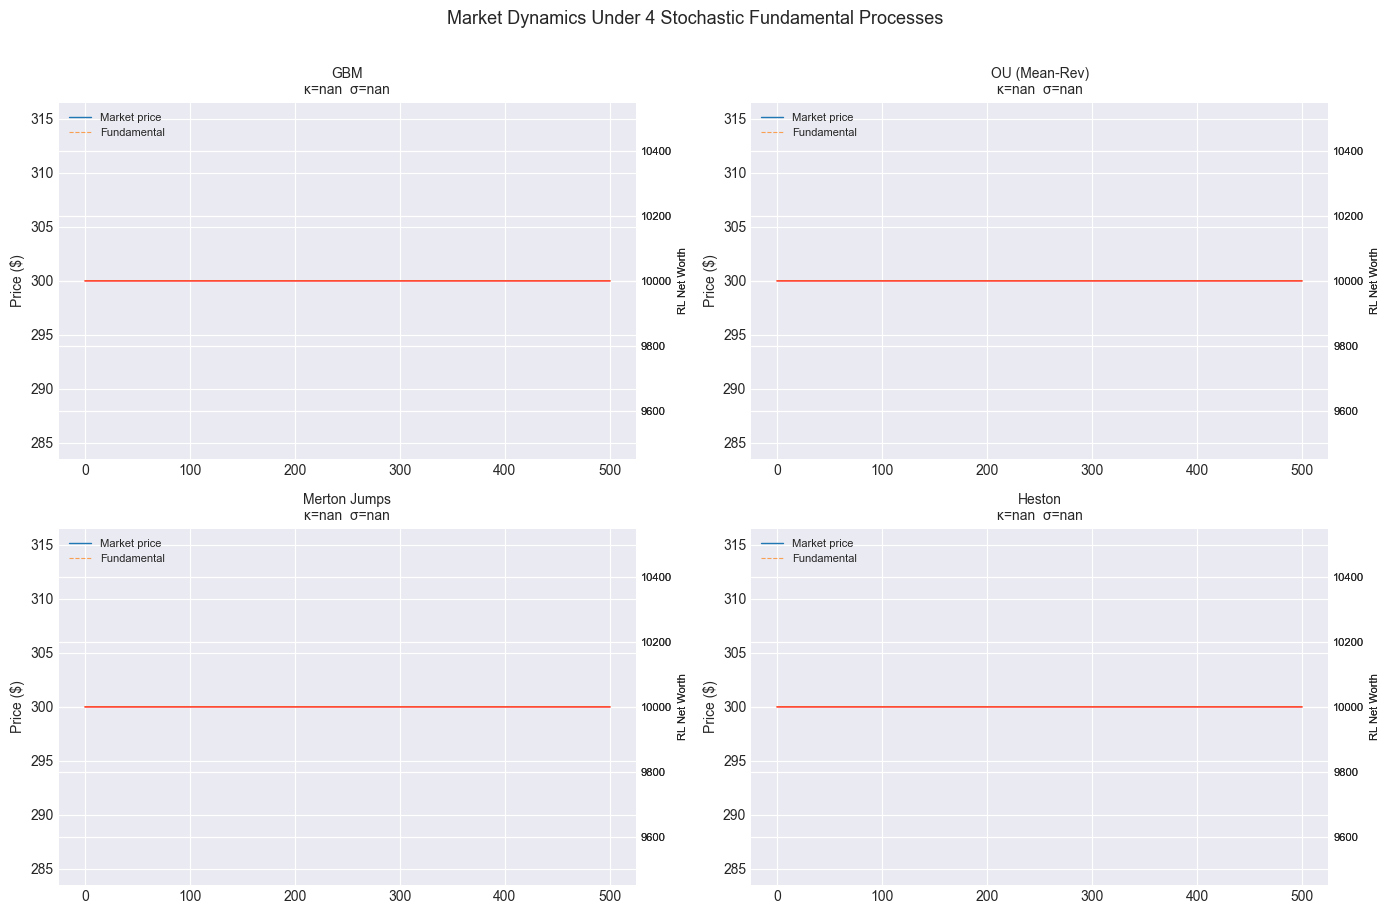

,Final Price,Return %,Kurtosis,|Ret| ACF(1),ATH β (×10⁻¹),QL Worth,DQN Worth
Process,,,,,,,
GBM,300.000,0.000,NaN,0.000,NaN,10000.000,10000.000
OU (Mean-Rev),300.000,0.000,NaN,0.000,NaN,10000.000,10000.000
Merton Jumps,300.000,0.000,NaN,0.000,NaN,10000.000,10000.000
Heston,300.000,0.000,NaN,0.000,NaN,10000.000,10000.000


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
cmap_lines = plt.cm.tab10

for ax, (proc_name, result) in zip(axes.flat, comparison_results.items()):
    prices = np.array(result.prices)
    fund = np.array(result.fundamental_path)
    ax.plot(prices, lw=1.0, label='Market price')
    ax.plot(fund[:len(prices)], lw=0.8, ls='--', alpha=0.7, label='Fundamental')

    # Shade RL agent wealth in background
    for a, c in [(ql_agent, 'orange'), (dqn_agent, 'red')]:
        wh = a.ledger.net_worth_history
        ax2 = ax.twinx()
        ax2.plot(wh, lw=1.2, color=c, alpha=0.7, label=type(a).__name__)
        ax2.set_ylabel('RL Net Worth', fontsize=8)
        ax2.tick_params(axis='y', labelsize=8)

    sf = stylized_facts(result.prices)
    ax.set_title(f'{proc_name}\nκ={sf["excess_kurtosis"]:.2f}  σ={sf["vol_daily"]:.5f}', fontsize=10)
    ax.set_ylabel('Price ($)')
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Market Dynamics Under 4 Stochastic Fundamental Processes', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
rows = []
for proc_name, result in comparison_results.items():
    sf = stylized_facts(result.prices)
    beta = ath_beta(result.prices, 10)
    rows.append({'Process': proc_name,
                 'Final Price': round(result.final_price, 1),
                 'Return %': round((result.final_price/300 - 1)*100, 1),
                 'Kurtosis': sf['excess_kurtosis'],
                 '|Ret| ACF(1)': sf['acf_abs_ret_1'],
                 'ATH β (×10⁻¹)': round(beta * 10, 3),
                 'QL Worth': round(ql_agent.ledger.net_worth(result.final_price), 0),
                 'DQN Worth': round(dqn_agent.ledger.net_worth(result.final_price), 0),
                })
display(pd.DataFrame(rows).set_index('Process'))

---
## Summary

| Component | Implementation |
|---|---|
| **Market** | Price-time LOB, double auction, trade log, OFI tracking |
| **Stochastic Processes** | GBM, OU, Merton Jump Diffusion, Heston Stochastic Volatility |
| **Agent Zoo** | FCN, TrendFollower (EMA crossover), MeanReversion (z-score), FCL (LLM) |
| **RL — Tabular** | Q-Learning: ε-greedy, Bellman update, 625-state discretization |
| **RL — Deep** | Double DQN: 8→64→64→3 numpy MLP, experience replay, target network |
| **Training** | Multi-episode loop, randomised process per episode, portfolio reset |
| **Analytics** | Stylized facts, ATH anomaly β, Sharpe, max drawdown, HMM regime detection |

### Next Steps
- Add **multi-asset** (portfolio RL across correlated stocks)
- Add **PPO / A2C** policy gradient agents via REINFORCE
- Integrate real tick data (TSE FLEX-FULL) for calibration
- Enable **Ollama LLM agents** by setting `n_llm > 0` in `SimConfig`
- Train on longer episodes with Heston to capture volatility clustering in RL strategy